In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [38]:
BATCH_SIZE = 128
LEARNING_RATE = 0.0001
EPOCHS = 100
LATENT_DIM = 32

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.13,), (0.31,)),
    transforms.Lambda(lambda x: x.view(-1))])

train_dataset = datasets.MNIST(root='data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='data', train=False, transform=transform, download=True)

In [39]:
# Data Loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [40]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=20):
        super().__init__()

        #encoder - сжатие
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )

        #decoder - восстановление
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim),
            nn.Tanh()
        )

    def forward(self, x):
        latent_x = self.encoder(x)
        decoded_x = self.decoder(latent_x)
        return decoded_x

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

In [41]:
model = AutoEncoder(input_dim=784, latent_dim=LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

train_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for data, _ in train_loader:
        data = data.to(device)

        reconstructed = model(data)
        loss = criterion(reconstructed, data)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f'Эпоха [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}')

Эпоха [1/100], Loss: 0.6437
Эпоха [2/100], Loss: 0.5126
Эпоха [3/100], Loss: 0.4830
Эпоха [4/100], Loss: 0.4631
Эпоха [5/100], Loss: 0.4505
Эпоха [6/100], Loss: 0.4418
Эпоха [7/100], Loss: 0.4351
Эпоха [8/100], Loss: 0.4299
Эпоха [9/100], Loss: 0.4253
Эпоха [10/100], Loss: 0.4211
Эпоха [11/100], Loss: 0.4176
Эпоха [12/100], Loss: 0.4146
Эпоха [13/100], Loss: 0.4120
Эпоха [14/100], Loss: 0.4097
Эпоха [15/100], Loss: 0.4076
Эпоха [16/100], Loss: 0.4050
Эпоха [17/100], Loss: 0.4030
Эпоха [18/100], Loss: 0.4012
Эпоха [19/100], Loss: 0.3997
Эпоха [20/100], Loss: 0.3981
Эпоха [21/100], Loss: 0.3968
Эпоха [22/100], Loss: 0.3955
Эпоха [23/100], Loss: 0.3942
Эпоха [24/100], Loss: 0.3929
Эпоха [25/100], Loss: 0.3917
Эпоха [26/100], Loss: 0.3905
Эпоха [27/100], Loss: 0.3895
Эпоха [28/100], Loss: 0.3885
Эпоха [29/100], Loss: 0.3875
Эпоха [30/100], Loss: 0.3866
Эпоха [31/100], Loss: 0.3857
Эпоха [32/100], Loss: 0.3849
Эпоха [33/100], Loss: 0.3841
Эпоха [34/100], Loss: 0.3834
Эпоха [35/100], Loss: 0

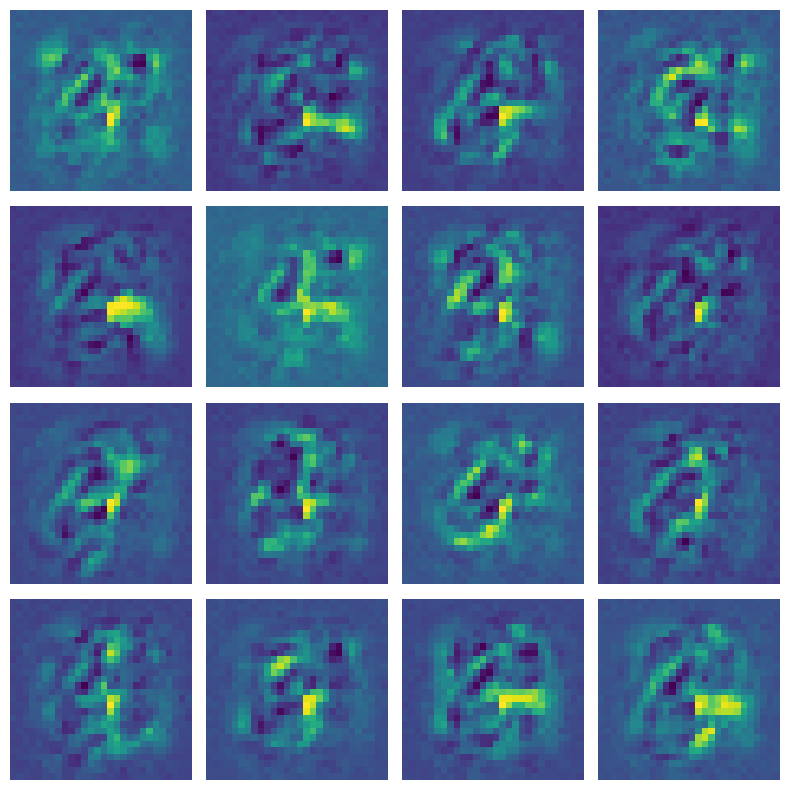

In [44]:
model.eval()

with torch.no_grad():
    random_vectors = torch.randn(16, LATENT_DIM).to(device)
    generated = model.decode(random_vectors)
    generated = (generated * 0.31) + 0.13
    generated = generated.view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated[i])
        ax.axis('off')

    plt.tight_layout()
    plt.show()